In [12]:
import operator
import uuid
import os

from dotenv import load_dotenv
from IPython.display import Image, display
from typing import Annotated, List, Literal, TypedDict
from langgraph.graph import END, START, StateGraph
from langgraph.types import Command, interrupt
from langgraph.checkpoint.memory import InMemorySaver
from langchain_groq import ChatGroq

In [2]:
load_dotenv()

True

# Nodes

In [2]:
class State(TypedDict):
    nlist: List[str]

In [3]:
def node_a(state: State) -> State:
    print(f"node a is receiving {state['nlist']}")
    note = "Hello World from Node a"
    return(State(nlist = [note]))

In [ ]:
builder = StateGraph(State)
builder.add_node("a", node_a)
builder.add_edge(START, "a")
builder.add_edge("a", END)
graph = builder.compile()

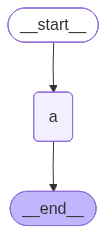

In [ ]:
display(Image(graph.get_graph().draw_mermaid_png()))
# print(graph.get_graph().draw_mermaid())

In [ ]:
initial_state = State(
    nlist = ["Hello Node a, how are you?"]
)
graph.invoke(initial_state)

node a is receiving ['Hello Node a, how are you?']


{'nlist': ['Hello World from Node a']}

# Edges

In [9]:
class EdgeState(TypedDict):
    nlist: Annotated[List[str], operator.add]

In [10]:
def node_a(state: State) -> State:
    print(f"Adding 'A' to {state['nlist']}")
    return(EdgeState(nlist = ["A"]))

def node_b(state: State) -> State:
    print(f"Adding 'B' to {state['nlist']}")
    return(EdgeState(nlist = ["B"]))

def node_c(state: State) -> State:
    print(f"Adding 'C' to {state['nlist']}")
    return(EdgeState(nlist = ["C"]))

def node_bb(state: State) -> State:
    print(f"Adding 'BB' to {state['nlist']}")
    return(EdgeState(nlist = ["BB"]))

def node_cc(state: State) -> State:
    print(f"Adding 'CC' to {state['nlist']}")
    return(EdgeState(nlist = ["CC"]))

def node_d(state: State) -> State:
    print(f"Adding 'D' to {state['nlist']}")
    return(EdgeState(nlist = ["D"]))

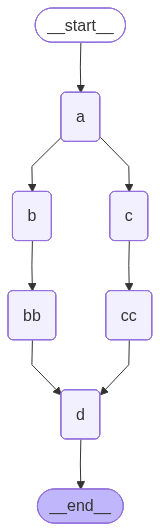

In [11]:
builder = StateGraph(EdgeState)

# Add nodes
builder.add_node("a", node_a)
builder.add_node("b", node_b)
builder.add_node("c", node_c)
builder.add_node("bb", node_bb)
builder.add_node("cc", node_cc)
builder.add_node("d", node_d)

# Add edges
builder.add_edge(START,"a")
builder.add_edge("a", "b")
builder.add_edge("a", "c")
builder.add_edge("b", "bb")
builder.add_edge("c", "cc")
builder.add_edge("bb", "d")
builder.add_edge("cc", "d")
builder.add_edge("d",END)

# Compile and display
graph = builder.compile()
display(Image(graph.get_graph().draw_mermaid_png()))

In [12]:
initial_state = EdgeState(
    nlist = ["Initial String:"]
)
graph.invoke(initial_state)

Adding 'A' to ['Initial String:']
Adding 'B' to ['Initial String:', 'A']
Adding 'C' to ['Initial String:', 'A']
Adding 'BB' to ['Initial String:', 'A', 'B', 'C']
Adding 'CC' to ['Initial String:', 'A', 'B', 'C']
Adding 'D' to ['Initial String:', 'A', 'B', 'C', 'BB', 'CC']


{'nlist': ['Initial String:', 'A', 'B', 'C', 'BB', 'CC', 'D']}

# Condition

In [13]:
class ConditionalState(TypedDict):
    nlist : Annotated[list[str], operator.add]   

In [14]:
def node_a(state: ConditionalState) -> Command[Literal["b", "c", END]]:
    select = state["nlist"][-1]
    if select == "b":
        next_node = "b"
    elif select == "c":
        next_node = "c"
    elif select == "q":
        next_node = END
    else:
        next_node = END

    return Command(
        update = ConditionalState(nlist = [select]),
        goto = [next_node]
    )

# def node_a(state: State):
#     return

def node_b(state: ConditionalState) -> ConditionalState:
    return(ConditionalState(nlist = ["B"]))
    
def node_c(state: ConditionalState) -> ConditionalState:
    return(ConditionalState(nlist = ["C"]))

In [15]:
def conditional_edge(state: ConditionalState) -> Literal["b", "c", END]:
    select = state["nlist"][-1]
    if select == "b":
        return "b"
    elif select == "c":
        return "c"
    elif select == "q":
        return END
    else:
        return END

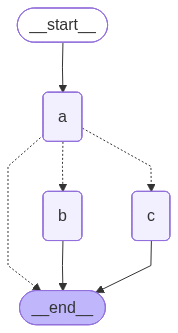

In [16]:
builder = StateGraph(ConditionalState)

# Add nodes
builder.add_node("a", node_a)
builder.add_node("b", node_b)
builder.add_node("c", node_c)

# Add edges
builder.add_edge(START, "a")
builder.add_edge("b", END)
builder.add_edge("c", END)
# builder.add_conditional_edges("a", conditional_edge)

# Compile and display
graph = builder.compile()
display(Image(graph.get_graph().draw_mermaid_png()))

In [19]:
user = input('b, c, or q to quit: ')

input_state = ConditionalState(
    nlist = [user]
)
graph.invoke(input_state)

{'nlist': ['q', 'q']}

In [20]:
while True:
    user = input('b, c, or q to quit: ')
    print(user)
    input_state = State(nlist =  [user])
    result = graph.invoke(input_state)
    print( result )
    if result['nlist'][-1] == "q":
        print("quit")
        break

b
{'nlist': ['b', 'b', 'B']}
e
{'nlist': ['e', 'e']}
q
{'nlist': ['q', 'q']}
quit


# Memory

In [22]:
memory = InMemorySaver()
config = {"configurable": {"thread_id": "1"}}

In [23]:
graph = builder.compile(checkpointer=memory)

In [25]:
while True:
    user = input('b, c, or q to quit: ')
    input_state = State(nlist = [user])
    result = graph.invoke(input_state, config )
    print( result )
    if result['nlist'][-1] == "q":
        print("quit")
        break

{'nlist': ['b', 'b', 'B', 'c', 'c', 'C', 'q', 'q', 'c', 'c', 'C']}
{'nlist': ['b', 'b', 'B', 'c', 'c', 'C', 'q', 'q', 'c', 'c', 'C', 'q', 'q']}
quit


# HITL

In [2]:
memory = InMemorySaver()
config = {"configurable": {"thread_id": "1"}}

In [3]:
class HITLState(TypedDict):
    nlist : Annotated[list[str], operator.add]  

In [4]:
def node_a(state: HITLState) -> Command[Literal["b", "c", END]]:
    print("Entered 'a' node")
    select = state["nlist"][-1]
    if select == "b":
        next_node = "b"
    elif select == "c":
        next_node = "c"
    elif select == "q":
        next_node = END
    else:
        admin = interrupt(f"Unexpected input '{select}'")
        print(admin)
        if admin == "continue":
            next_node = "b"
        else:
            next_node = END
            select = "q"
            
    return Command(
        update = HITLState(nlist = [select]),
        goto = next_node
    )


def node_b (state: HITLState) -> HITLState:
    return(HITLState(nlist = ["B"]))

def node_c (state: HITLState) -> HITLState:
    return(HITLState(nlist = ["C"]))

In [5]:
builder = StateGraph(HITLState)

# Add nodes
builder.add_node("a", node_a)
builder.add_node("b", node_b)
builder.add_node("c", node_c)

# Add edges
builder.add_edge(START,"a")
builder.add_edge("b", END)
builder.add_edge("c", END)

# Compile
graph = builder.compile(checkpointer=memory)

In [7]:
while True:
    user = input('b, c, or q to quit: ')
    input_state = HITLState(nlist = [user])
    result = graph.invoke(input_state, config)

    if '__interrupt__' in result:
        print(f"Interrupt:{result}")
        msg = result['__interrupt__'][-1].value
        print(msg)
        human = input(f"\n{msg}: ")

        human_response = Command(
            resume = human
        )
        result = graph.invoke(human_response, config)
        
    if result['nlist'][-1] == "q":
        print("quit")
        break


Entered 'a' node
Entered 'a' node
Entered 'a' node
Entered 'a' node
Interrupt:{'nlist': ['b', 'b', 'B', 'b', 'b', 'B', 'c', 'c', 'C', 'g'], '__interrupt__': [Interrupt(value="Unexpected input 'g'", id='8b5ca84e29e8285e2be5bc1d7d597c0a')]}
Unexpected input 'g'
Entered 'a' node

quit


# EmailAgent

In [4]:
class EmailClassification(TypedDict):
    intent: Literal["question", "bug", "billing", "feature", "complex"]
    urgency: Literal["low", "medium", "high", "critical"]
    topic: str
    summary: str

class EmailAgentState(TypedDict):
    # Raw email data
    email_content: str
    sender_email: str
    email_id: str

    # Classification result
    classification: EmailClassification | None

    # Bug tracking
    ticket_id: str | None

    # Raw search results
    search_results: list[str] | None
    customer_history: dict | None

    # Generated content
    draft_response: str | None

In [13]:
llm = ChatGroq(
    model="llama-3.3-70b-versatile" ,
    groq_api_key=os.getenv("GROQ_API_KEY") ,
    temperature=0 ,
)

In [14]:
def read_email(state: EmailAgentState) -> EmailAgentState:
    """Extract and parse email content"""
    pass

def classify_intent(state: EmailAgentState) -> EmailAgentState:
    """Use LLM to classify email intent and urgency, then route accordingly"""

    # Create structured LLM that returns EmailClassification dict
    structured_llm = llm.with_structured_output(EmailClassification)

    classification_prompt = f"""
    Analyze this customer email and classify it:

    Email: {state['email_content']}
    From: {state['sender_email']}

    Provide classification, including intent, urgency, topic, and summary
    """

    # Get structured response directly as a dict
    classification = structured_llm.invoke(classification_prompt)

    # Store classification as a single dict in state
    return {"classification": classification}

def search_documentation(state: EmailAgentState) -> EmailAgentState:
    """Search knowledge base for relevant information"""

    # Build search query from classification
    classification = state.get('classification', {})
    query = f"{classification.get('intent', '')} {classification.get('topic', '')}"

    try:
        # Implement search logic here
        search_results = [
            "--Search_result_1--",
            "--Search_result_2--",
            "--Search_result_3--"
        ]
    except SearchAPIError as e:
        # For recoverable search errors, store error and continue
        search_results = [f"Search temporarily unavailable: {str[e]}"]

    return {"search_results": search_results} # Raw search results or error

def bug_tracking(state: EmailAgentState) -> EmailAgentState:
    """Create or update bug tracking ticket"""

    # Create ticket in your bug tracking system
    ticket_id = f"BUG_{uuid.uuid4()}"

    return {"ticket_id": ticket_id}

def write_response(state: EmailAgentState) -> Command[Literal["human_review", "send_reply"]]:
    "Generate response using context and route based on quality"""

    classification = state.get('classification', {})

    # Format context from raw state data on demand
    context_sections = []

    if state.get('search_results'):
        # Format search results for the prompt
        formatted_docs = "\n".join([f"- {doc}" for doc in state['search_results']])
        context_sections.append(f"Relevant documentation:\n{formatted_docs}")

    if state.get('customer_history'):
        # Format customer data for the prompt
        context_sections.append(f"Customer tier: {state['customer_history'].get('tier', 'standard')}")

    # Build the prompt with formatted context
    draft_prompt = f"""
    Draft a response to this customer email:
    {state['email_content']}

    Email intent: {classification.get('intent', 'unkown')}
    Urgency level: {classification.get('urgency', 'medium')}

    {chr(10).join(context_sections)}

    Guidelines:
    - Be professional and helpful
    - Address their specific concern
    - Use the provided documentation when relevant
    - Be brief
    """

    response = llm.invoke(draft_prompt)

    # Determine if human review is needed based on urgency and intent
    needs_review = (
        classification.get('urgency') in ['high', 'critical'] or
        classification.get('intent') == 'complex'
    )

    # Route to the appropriate next node
    if needs_review:
        goto = "human_review"
        print("Needs approval")
    else:
        goto = "send_reply"

    return Command(
        update = {"draft_response": response.content},
        goto = goto
    )

def human_review(state: EmailAgentState) -> Command[Literal["send_reply", END]]:
    """Pause for human review using interrupt and route based on decision"""

    classification = state.get('classification', {})

    # Interrupt() must come first - any code before it will re-run on resume
    human_decision = interrupt({
        "email_id": state['email_id'],
        "original_email": state['email_content'],
        "draft_response": state.get('draft_response', ""),
        "urgency": classification.get('urgency'),
        "intent": classification.get('intent'),
        "action": "Please review and approve/edit this response"
    })

    # Now process the human's decision
    if human_decision.get("approved"):
        return Command(
            update = {"draft_response": human_decision.get("edited_response", state['draft_response'])},
            goto = "send_reply"
        )
    else:
        # Rejection means human will handle directly
        return Command(update = {}, goto = END)

def send_reply(state: EmailAgentState) -> EmailAgentState:
    """Send the email response"""
    # Integrate with a email service
    print(f"Sending reply: {state['draft_response'][:60]}...")
    return {}

In [15]:
# Create the graph
builder = StateGraph(EmailAgentState)

# Add nodes
builder.add_node("read_email", read_email)
builder.add_node("classify_intent", classify_intent)
builder.add_node("search_documentation", search_documentation)
builder.add_node("bug_tracking", bug_tracking)
builder.add_node("write_response", write_response)
builder.add_node("human_review", human_review)
builder.add_node("send_reply", send_reply)

# Add edges
builder.add_edge(START, "read_email")
builder.add_edge("read_email", "classify_intent")
builder.add_edge("classify_intent", "search_documentation")
builder.add_edge("classify_intent", "bug_tracking")
builder.add_edge("search_documentation", "write_response")
builder.add_edge("bug_tracking", "write_response")
builder.add_edge("send_reply", END)

memory = InMemorySaver()
app = builder.compile(checkpointer = memory)

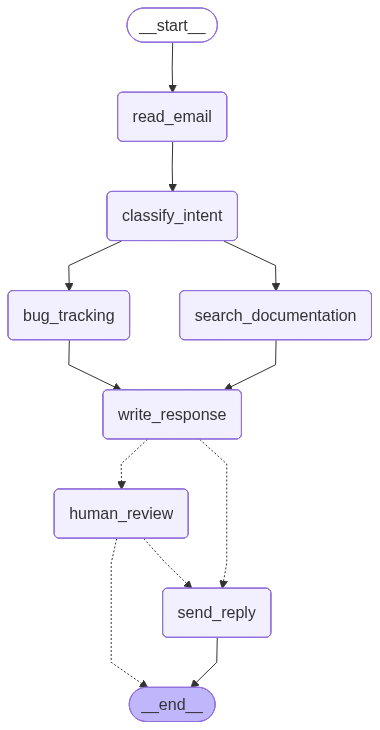

In [16]:
display(Image(app.get_graph().draw_mermaid_png()))

In [17]:
# Test with urgent billing issue
initial_state = {
    "email_content": "I was charged twice for my subscription! This is urgent!",
    "sender_email": "customer@example.com",
    "email_id": "email_123"
}

# Run with a thread_id for persistence
config = {"configurable": {"thread_id": "customer_123"}}
result = app.invoke(initial_state, config)

Needs approval


In [18]:
# The graph will pause at human_review
print(f"Draft ready for review: {result['draft_response'][:60]}...\n")

# Provide human input to resume
human_response = Command(
    resume = {
        "approved": True
    }
)

# Resume execution
final_result = app.invoke(human_response, config)
print("Email sent successfully!")

Draft ready for review: Subject: Urgent: Duplicate Subscription Charge

Dear [Custom...

Sending reply: Subject: Urgent: Duplicate Subscription Charge

Dear [Custom...
Email sent successfully!


In [19]:
email_content = [
    "I was charged two times for my subscription! This is urgent!",
    "I was wondering if this was available in blue?",
    "Can you tell me how long the sale is on?",
    "The tire won't stay on the car!",
    "My subscription is going to end in a few months, what is the new rate?"
]
needs_approval = []

for i, content in enumerate(email_content): 

    initial_state = {
        "email_content": content,
        "sender_email": "customer@example.com",
        "email_id": f"email_{i}",
    }
    print(f"{initial_state['email_id']}: ", end="")

    thread_id = uuid.uuid4()
    config =  {"configurable": {"thread_id": thread_id}}
    result = app.invoke(initial_state, config)
    if "__interrupt__" in result.keys():
        result['thread_id'] = thread_id
        needs_approval.append(result)

email_0: Needs approval
email_1: Sending reply: Dear Customer,

Thank you for your inquiry. I've checked on ...
email_2: Sending reply: Subject: Re: Sale Duration Inquiry

Dear Customer,

Thank yo...
email_3: Needs approval
email_4: Sending reply: Subject: Upcoming Subscription Renewal and New Rate

Dear [C...
